Explore Statistical Arbitrage Strategy

In [2]:
from binance.client import Client as bnb_client
from datetime import datetime
import pandas as pd 
import numpy as np 

In [4]:
client = bnb_client(tld='US')
client

In [26]:
def get_binance_px(symbol,freq,start_ts='2016-01-01',end_ts='2025-12-31'):
    data = client.get_historical_klines(symbol,freq,start_ts,end_ts)
    columns = ['open_time','open','high','low','close','volume','close_time','quote_volume',
    'num_trades','taker_base_volume','taker_quote_volume','ignore']
    data = pd.DataFrame(data,columns=columns)
    data['open_time'] = data['open_time'].map(lambda x:datetime.utcfromtimestamp(x/1000))
    data['close_time'] = data['close_time'].map(lambda x:datetime.utcfromtimestamp(x/1000))
    return data

In [27]:
freq = '4h'
univ = ['BTCUSDT','ETHUSDT','ADAUSDT','BNBUSDT','XRPUSDT','DOTUSDT','POLUSDT']
px = {}
for x in univ:
    data = get_binance_px(x,freq)
    px[x] = data.set_index('open_time')['close']
px = pd.DataFrame(px).astype(float)
px

,BTCUSDT,ETHUSDT,ADAUSDT,BNBUSDT,XRPUSDT,DOTUSDT,POLUSDT
open_time,,,,,,,
2019-09-23 08:00:00,9930.13,209.55,NaN,19.8787,0.27311,NaN,NaN
2019-09-23 12:00:00,9930.13,209.55,NaN,19.8787,0.27311,NaN,NaN
2019-09-23 16:00:00,9930.13,209.55,NaN,19.8787,0.27311,NaN,NaN
2019-09-23 20:00:00,9930.13,209.55,NaN,19.8787,0.27311,NaN,NaN
2019-09-24 00:00:00,9930.13,209.55,NaN,19.8787,0.27311,NaN,NaN
...,...,...,...,...,...,...,...
2025-12-30 08:00:00,87874.64,2977.11,0.3545,854.6100,1.86160,1.823,0.1034
2025-12-30 12:00:00,89108.11,2997.68,0.3538,862.2900,1.87660,1.838,0.1034
2025-12-30 16:00:00,88187.55,2973.97,0.3519,857.8400,1.87710,1.813,0.1030


In [28]:
len(px.index)

13739

In [29]:
reindex = pd.date_range(px.index[0],px.index[-1],freq=freq)

In [30]:
#index these
[i for i in reindex if i not in px.index]

[Timestamp('2020-04-28 04:00:00'),
 Timestamp('2020-04-28 08:00:00'),
 Timestamp('2020-07-09 04:00:00'),
 Timestamp('2020-07-09 08:00:00'),
 Timestamp('2021-06-22 04:00:00'),
 Timestamp('2023-02-06 08:00:00')]

In [31]:
px = px.reindex(pd.date_range(px.index[0],px.index[-1],freq=freq))
ret = px.pct_change()
ret


/var/folders/gq/rc3my0dd7s55zk5lpnbzp_rw0000gn/T/ipykernel_10637/719867275.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret = px.pct_change()


,BTCUSDT,ETHUSDT,ADAUSDT,BNBUSDT,XRPUSDT,DOTUSDT,POLUSDT
2019-09-23 08:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09-23 12:00:00,0.000000,0.000000,NaN,0.000000,0.000000,NaN,NaN
2019-09-23 16:00:00,0.000000,0.000000,NaN,0.000000,0.000000,NaN,NaN
2019-09-23 20:00:00,0.000000,0.000000,NaN,0.000000,0.000000,NaN,NaN
2019-09-24 00:00:00,0.000000,0.000000,NaN,0.000000,0.000000,NaN,NaN
...,...,...,...,...,...,...,...
2025-12-30 08:00:00,0.003998,0.008499,0.002262,0.000796,0.000537,0.003855,-0.005769
2025-12-30 12:00:00,0.014037,0.006909,-0.001975,0.008987,0.008058,0.008228,0.000000
2025-12-30 16:00:00,-0.010331,-0.007909,-0.005370,-0.005161,0.000266,-0.013602,-0.003868
2025-12-30 20:00:00,0.002773,0.000208,-0.001137,0.002366,-0.000160,-0.003309,0.003883


Momentum checking across 4,8,16,20,24hours

In [32]:
strats = {}
for hor in [1,2,3,4,5,6]:
    avg_ret = ret.rolling(hor,min_periods=1).mean().rank(1)
    avg_ret = avg_ret.subtract(avg_ret.mean(1),0)
    avg_ret = avg_ret.divide(avg_ret.abs().sum(1),0)
    strats[hor] = (avg_ret.shift()*ret).sum(1)
strats = pd.DataFrame(strats)

In [33]:
sharp_r = strats.mean()/strats.std()*np.sqrt(252*24/4)
sharp_r

1   -2.546862
2   -1.168105
3   -0.421206
4   -0.065021
5   -0.016918
6   -0.340243
dtype: float64

/var/folders/gq/rc3my0dd7s55zk5lpnbzp_rw0000gn/T/ipykernel_10637/2023984192.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  sr = strats.resample('A').mean()/strats.resample('A').std()*np.sqrt(252*24/4)


<Axes: >

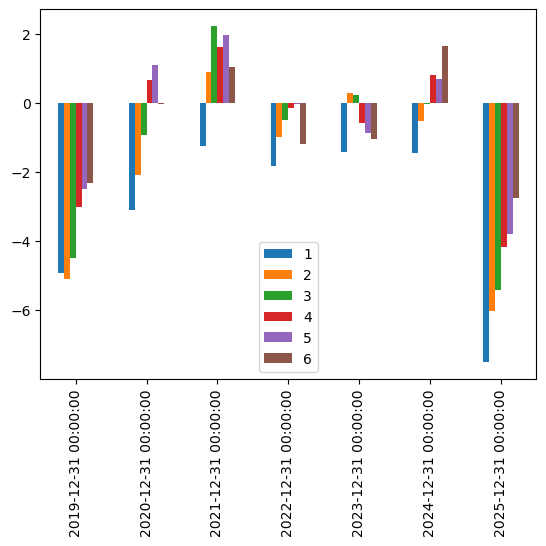

In [34]:
sr = strats.resample('A').mean()/strats.resample('A').std()*np.sqrt(252*24/4)
sr.plot(kind='bar')

skip the most recent bars, shift two rows to see the result

In [69]:
strats = {}
drawdowns = {}
for hor in [1,2,3,4,5,6]:
    avg_ret = ret.rolling(hor,min_periods=1).mean().rank(1)
    avg_ret = avg_ret.subtract(avg_ret.mean(1),0)
    avg_ret = avg_ret.divide(avg_ret.abs().sum(1),0)
    strats[hor] = (avg_ret.shift(2)*ret).sum(1)
    drawdowns[f'drawdown_{hor}'] = drawdown(strats[hor])
strats = pd.DataFrame(strats)
drawdowns = pd.DataFrame(drawdowns)

In [72]:
drawdowns.min(axis=0)

drawdown_1   -0.357388
drawdown_2   -0.346433
drawdown_3   -0.378870
drawdown_4   -0.671645
drawdown_5   -0.760676
drawdown_6   -0.727228
dtype: float64

In [65]:
strats

,1,drawdown_1,2,drawdown_2,3,drawdown_3,4,drawdown_4,5,drawdown_5,6,drawdown_6
2019-09-23 08:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2019-09-23 12:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2019-09-23 16:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2019-09-23 20:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2019-09-24 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-30 08:00:00,0.002495,-0.299028,0.001693,-0.248304,0.002932,-0.250191,0.002024,-0.414851,0.000270,-0.357197,-0.000105,-0.468127
2025-12-30 12:00:00,-0.002443,-0.300740,0.002215,-0.246639,0.000592,-0.249747,0.004203,-0.412392,0.004970,-0.354003,0.003973,-0.466013
2025-12-30 16:00:00,-0.003480,-0.303174,-0.004158,-0.249771,-0.000013,-0.249756,-0.000013,-0.412400,-0.001008,-0.354654,-0.000578,-0.466322
2025-12-30 20:00:00,0.000431,-0.302873,-0.000316,-0.250008,-0.001116,-0.250594,0.000209,-0.412277,-0.000005,-0.354657,0.000624,-0.465989


<Axes: >

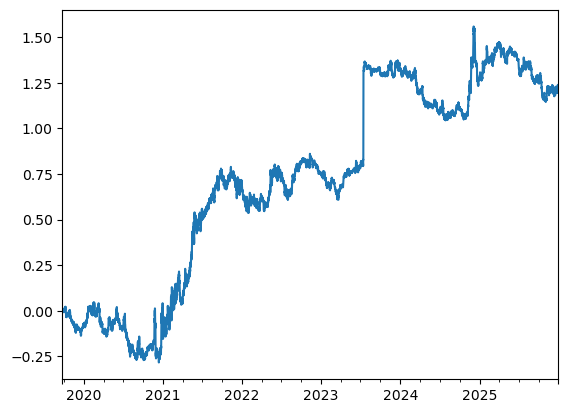

In [66]:
strats.iloc[:,0].cumsum().plot(kind='line')

<Axes: >

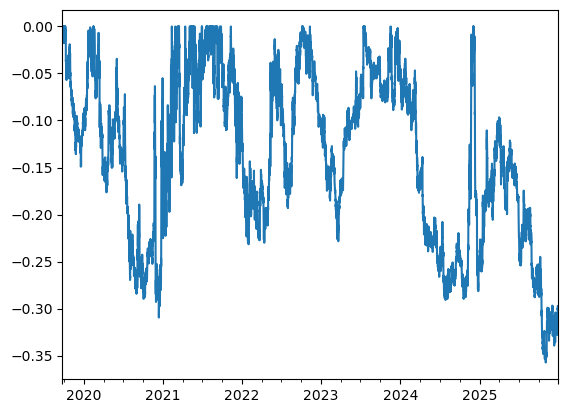

In [68]:
strats.iloc[:,1].plot(kind='line')

/var/folders/gq/rc3my0dd7s55zk5lpnbzp_rw0000gn/T/ipykernel_10637/2023984192.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  sr = strats.resample('A').mean()/strats.resample('A').std()*np.sqrt(252*24/4)


<Axes: >

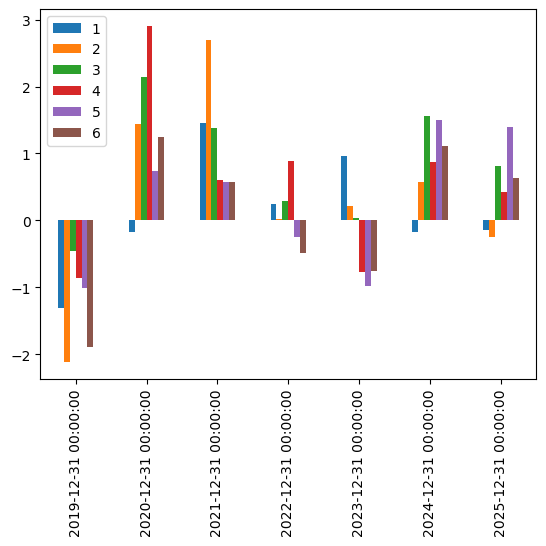

In [36]:
sr = strats.resample('A').mean()/strats.resample('A').std()*np.sqrt(252*24/4)
sr.plot(kind='bar')

In [39]:
sr = sr.mean()/sr.std()*np.sqrt(252*24/4)
sr

1     5.347761
2     9.618155
3    34.610843
4    17.841316
5    10.498889
6     2.078903
dtype: float64

In [63]:
# def drawdown(px):
#     return (px / px.expanding(min_periods=1).max() - 1)
def drawdown(returns):
    equity = (1 + returns).cumprod()
    return equity / equity.cummax() - 1

<Axes: >

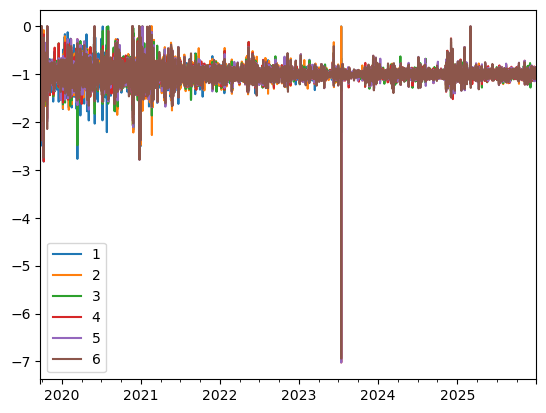

In [46]:
# strats['drawdown'] = [strats[i].apply(drawdown) for i in range(strats.shape[1])]
drawdowns = strats.apply(drawdown)
drawdowns.plot()